In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('cleanedstockprice.csv')


In [8]:
last_date =df['date'].max()
first_date = df['date'].min()
print(last_date , first_date)

2017-12-29 2014-01-02


In [9]:
Top_10_volume = df.groupby('symbol')['volume'].sum().sort_values(ascending=False).head(10)
print(Top_10_volume)

symbol
BAC     89988444028
AAPL    45485758169
GE      41734050117
AMD     33522535638
F       33144701045
MSFT    30927601441
FB      29432418373
MU      28158553783
CHK     28080599383
INTC    27351266285
Name: volume, dtype: int64


**Line chart**

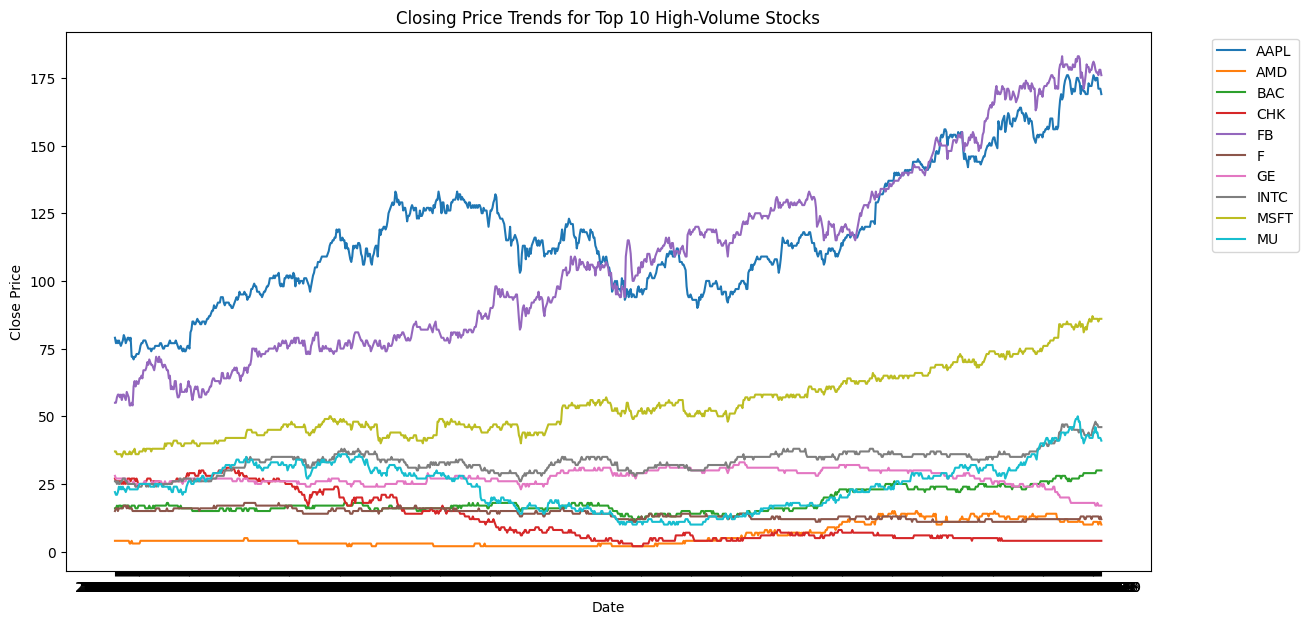

In [14]:
# 1. Find the top 10 symbols by total volume
top_10_symbols = df.groupby('symbol')['volume'].sum().nlargest(10).index

# 2. Filter the original dataframe to only include these 10 stocks
top_10_df = df[df['symbol'].isin(top_10_symbols)]
plt.figure(figsize=(14, 7))
sns.lineplot(data=top_10_df, x='date', y='close', hue='symbol')

plt.title('Closing Price Trends for Top 10 High-Volume Stocks')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.savefig('trendtopten_trend.png', dpi=300, bbox_inches='tight')
plt.show()

**Bar chart
**

/tmp/ipython-input-1983315708.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_volume, x='symbol', y='volume', palette='viridis')


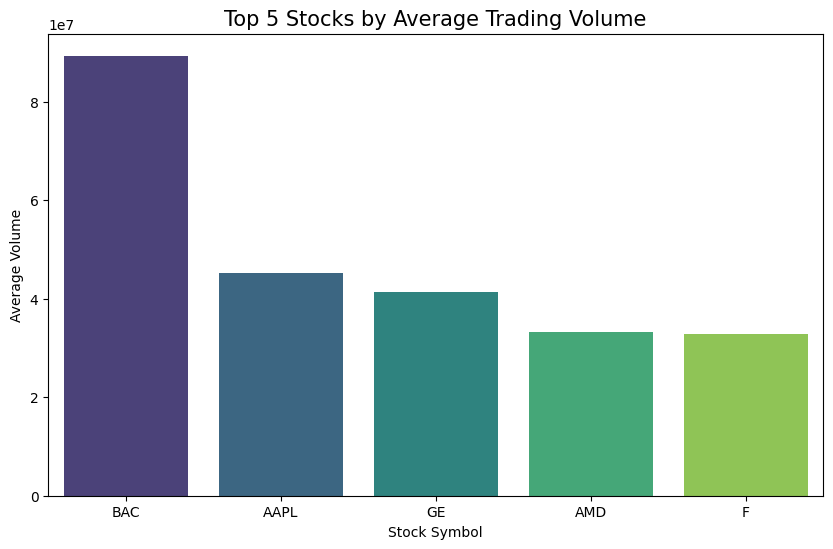

In [11]:
# Grouping data for the plot
top_5_volume = df.groupby('symbol')['volume'].mean().sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_volume, x='symbol', y='volume', palette='viridis')

plt.title('Top 5 Stocks by Average Trading Volume', fontsize=15)
plt.xlabel('Stock Symbol')
plt.ylabel('Average Volume')

plt.savefig('top_volume_comparison.png', dpi=300)
plt.show()

**Scatter plot**

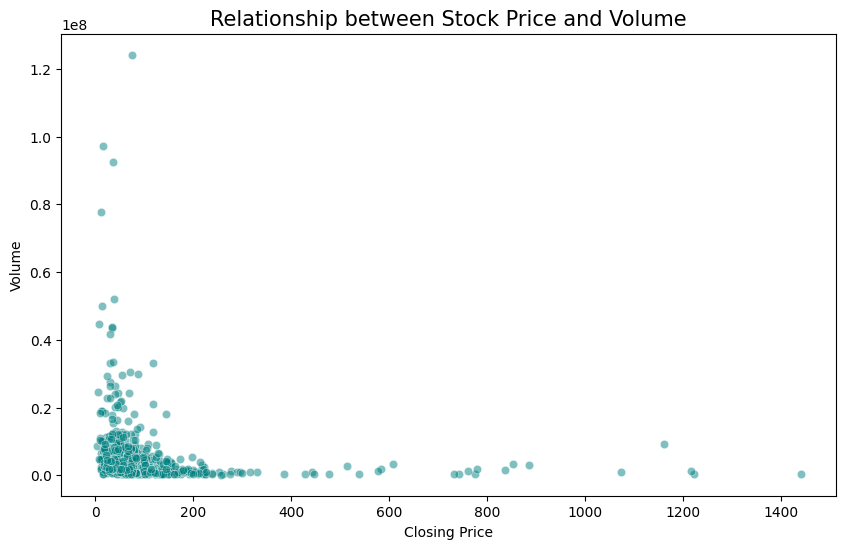

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(1000), x='close', y='volume', alpha=0.5, color='teal')

plt.title('Relationship between Stock Price and Volume', fontsize=15)
plt.xlabel('Closing Price')
plt.ylabel('Volume')

plt.savefig('price_vs_volume_scatter.png', dpi=300)
plt.show()